In [1]:
%reset -f
import sys
import glob
import os
from os.path import dirname, join as pjoin
# sys.path.append('C:\\jupyter_notebooks\\py_code')
sys.path.append('C:\\Users\Eva\Desktop\ImagingCode')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pickle
import random
import xarray as xr
import pandas as pd
import h5py
import scipy.io as sio
# Load optimizers
import statsmodels.api as sm
from scipy import stats
from scipy.optimize import minimize, basinhopping, curve_fit
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.stats import mannwhitneyu

import BD_SciAdv as BD
plt_colors = BD.plt_color_dir()
save_dir = 'C:\\Users\\Eva\\Desktop\\Manuscript2025\\Figures\\4'


In [2]:
def process_data(data_dir, data_dir2, n_back=15, is_long_to_short=None):
    os.chdir(data_dir)
    list_of_files = glob.glob('*.mat')
    median_tau_list = []
    median_abs_beta_list = []
    
    all_tau_pairs_short = []  
    all_tau_pairs_long = []   
    all_beta_pairs_short = [] 
    all_beta_pairs_long = []  

    # Lists to store short-only and long-only modulated cells
    all_short_only_tau = []
    all_short_only_beta = []
    all_long_only_tau = []
    all_long_only_beta = []
    median_tau_short_only_list = []
    median_tau_long_only_list = []
    median_abs_beta_short_only_list = []
    median_abs_beta_long_only_list = []
    
    # If is_long_to_short is not provided, try to determine from the directory name
    if is_long_to_short is None:
        is_long_to_short = 'long_to_short' in data_dir
    
    for file in list_of_files:
        mouse = file[0:5]
        area = file[20:-4]
        date1 = file[6:12]
        date2 = file[13:19]
        session1 = mouse + '_' + date1
        session2 = mouse + '_' + date2
        print(area, session1, session2)
        output_xarray1 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\across_task_matching','sse_{}_{}hist_updated.nc'.format(session1,n_back)))
        output_xarray2 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\across_task_matching','sse_{}_{}hist_updated.nc'.format(session2,n_back)))
        match_ss = pjoin(data_dir, '{}_{}_{}_{}.mat'.format(mouse,date1,date2,area))
        match_ss_contents = sio.loadmat(match_ss,squeeze_me=True)
        Mapping = match_ss_contents['roiMatchData']['allSessionMapping']
        ss1_mapped = Mapping.item()[:,0]-1
        ss2_mapped = Mapping.item()[:,1]-1
        
        out_pd1 = output_xarray1.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd1['tau_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).tau_RC 
        out_pd1['tau_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd1['crit_sig'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd1['crit_sig2'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05  #0.1
        out_pd1['crit_sig_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd1['crit_sig_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss1 = out_pd1.loc[ss1_mapped].reset_index()
        
            
        out_pd2 = output_xarray2.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd2['tau_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).tau_RC
        out_pd2['tau_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd2['crit_sig'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd2['crit_sig2'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05  #0.1
        out_pd2['crit_sig_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd2['crit_sig_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss2 = out_pd2.loc[ss2_mapped].reset_index()
        

        if is_long_to_short:
            # For long-to-short data, ss1 is long and ss2 is short
            short_session = matched_ss2
            long_session = matched_ss1
            short_total = len(out_pd2)
            long_total = len(out_pd1)
            print(f"Long-to-Short mapping: session1={session1} (Long), session2={session2} (Short)")
        else:
            # For short-to-long data, ss1 is short and ss2 is long
            short_session = matched_ss1
            long_session = matched_ss2
            short_total = len(out_pd1)
            long_total = len(out_pd2)
            print(f"Short-to-Long mapping: session1={session1} (Short), session2={session2} (Long)")

        
        matched_short_cell = short_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
        matched_long_cell = long_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
        
        matched_sig_index = np.array(matched_short_cell.index)
        matched_short_cell_beta = short_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'beta_RC']
        matched_long_cell_beta = long_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'beta_RC']    

        # Store tau and beta pairs for correlation analysis
        all_tau_pairs_short.append(matched_short_cell)
        all_tau_pairs_long.append(matched_long_cell)
        all_beta_pairs_short.append(matched_short_cell_beta)
        all_beta_pairs_long.append(matched_long_cell_beta)

        # Analyze short-only modulated cells
        short_only_cell = short_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig2']==False)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
        short_only_cell_beta = short_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig2']==False)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'beta_RC']

        # Analyze long-only modulated cells
        long_only_cell = long_session.loc[(short_session['crit_sig2']==False)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
        long_only_cell_beta = long_session.loc[(short_session['crit_sig2']==False)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'beta_RC']

        # Store the new cell groups for analysis
        all_short_only_tau.append(short_only_cell)
        all_short_only_beta.append(short_only_cell_beta)
        all_long_only_tau.append(long_only_cell)
        all_long_only_beta.append(long_only_cell_beta)

        # Calculate medians for the new groups
        median_tau_short_only = np.median(short_only_cell) if len(short_only_cell) > 0 else np.nan
        median_tau_long_only = np.median(long_only_cell) if len(long_only_cell) > 0 else np.nan
        median_beta_short_only = np.median(abs(short_only_cell_beta)) if len(short_only_cell_beta) > 0 else np.nan
        median_beta_long_only = np.median(abs(long_only_cell_beta)) if len(long_only_cell_beta) > 0 else np.nan

        # Store the medians
        median_tau_short_only_list.append(median_tau_short_only)
        median_tau_long_only_list.append(median_tau_long_only)
        median_abs_beta_short_only_list.append(median_beta_short_only)
        median_abs_beta_long_only_list.append(median_beta_long_only)

#         # Print median values for this session pair
#         print(f"{mouse}_{date1} {mouse}_{date2} median overlapped tau {np.median(matched_short_cell):.3f} 
#               {np.median(matched_long_cell):.3f} median non-overlapped tau {median_tau_short_only:.3f} 
#               {median_tau_long_only:.3f}")

        median_tau_short = np.median(matched_short_cell)
        median_tau_long = np.median(matched_long_cell)
        median_tau_list.append([median_tau_short, median_tau_long])
        
        median_beta_short = np.median(abs(matched_short_cell_beta))
        median_beta_long = np.median(abs(matched_long_cell_beta))
        median_abs_beta_list.append([median_beta_short, median_beta_long])
    
    
    return (median_tau_list, median_abs_beta_list, 
            all_tau_pairs_short, all_tau_pairs_long, 
            all_beta_pairs_short, all_beta_pairs_long,
            all_short_only_tau, all_short_only_beta,
            all_long_only_tau, all_long_only_beta,
            median_tau_short_only_list, median_tau_long_only_list,
            median_abs_beta_short_only_list, median_abs_beta_long_only_list)

In [3]:
def process_short_to_short_data(data_dir, data_dir2, n_back=15):
    """Process data for short-to-short comparisons.
    
    Args:
        data_dir: Directory containing matching files
        data_dir2: Base directory for imaging data
        n_back: Number of bins for the history model
    """
    os.chdir(data_dir)
    list_of_files = glob.glob('*.mat')
    median_tau_list = []
    median_abs_beta_list = []
    
    # Lists to store all tau and beta pairs for correlation analysis
    all_tau_pairs1 = []
    all_tau_pairs2 = []
    all_beta_pairs1 = []
    all_beta_pairs2 = []
    
    # Lists to store non-overlapping neurons
    all_short1_only_tau_ss = []
    all_short1_only_beta_ss = []
    all_short2_only_tau_ss = []
    all_short2_only_beta_ss = []
    median_tau_short1_only_list_ss = []
    median_tau_short2_only_list_ss = []
    median_abs_beta_short1_only_list_ss = []
    median_abs_beta_short2_only_list_ss = []
    
    for file in list_of_files:
        mouse = file[0:5]
        area = file[20:-4]
        date1 = file[6:12]
        date2 = file[13:19]
        session1 = mouse + '_' + date1
        session2 = mouse + '_' + date2
        
        output_xarray1 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\within_task_matching','sse_{}_{}hist_updated.nc'.format(session1,n_back)))
        output_xarray2 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\within_task_matching','sse_{}_{}hist_updated.nc'.format(session2,n_back)))
        match_ss = pjoin(data_dir, '{}_{}_{}_{}.mat'.format(mouse,date1,date2,area))
        match_ss_contents = sio.loadmat(match_ss,squeeze_me=True)
        Mapping = match_ss_contents['roiMatchData']['allSessionMapping']
        ss1_mapped = Mapping.item()[:,0]-1
        ss2_mapped = Mapping.item()[:,1]-1
        
        out_pd1 = output_xarray1.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd1['tau_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).tau_RC 
        out_pd1['tau_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd1['crit_sig'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd1['crit_sig2'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05  #0.1
        out_pd1['crit_sig_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd1['crit_sig_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss1 = out_pd1.loc[ss1_mapped].reset_index()
            
        out_pd2 = output_xarray2.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd2['tau_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).tau_RC
        out_pd2['tau_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd2['crit_sig'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd2['crit_sig2'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05  #0.1
        out_pd2['crit_sig_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd2['crit_sig_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss2 = out_pd2.loc[ss2_mapped].reset_index()

        matched_cell1 = matched_ss1.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        matched_cell2 = matched_ss2.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        
        matched_cell1_beta = matched_ss1.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'beta_RC']
        matched_cell2_beta = matched_ss2.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'beta_RC']    

        # Store tau and beta pairs for correlation analysis
        all_tau_pairs1.append(matched_cell1)
        all_tau_pairs2.append(matched_cell2)
        all_beta_pairs1.append(matched_cell1_beta)
        all_beta_pairs2.append(matched_cell2_beta)

        # Analyze non-overlapping neurons for short-to-short
        short1_only_cell_ss = matched_ss1.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig2']==False)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        short1_only_cell_beta_ss = matched_ss1.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig2']==False)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'beta_RC']

        short2_only_cell_ss = matched_ss2.loc[(matched_ss1['crit_sig2']==False)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        short2_only_cell_beta_ss = matched_ss2.loc[(matched_ss1['crit_sig2']==False)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'beta_RC']

        # Store non-overlapping neurons
        all_short1_only_tau_ss.append(short1_only_cell_ss)
        all_short1_only_beta_ss.append(short1_only_cell_beta_ss)
        all_short2_only_tau_ss.append(short2_only_cell_ss)
        all_short2_only_beta_ss.append(short2_only_cell_beta_ss)

        # Calculate medians for non-overlapping neurons
        median_tau_short1_only_ss = np.median(short1_only_cell_ss) if len(short1_only_cell_ss) > 0 else np.nan
        median_tau_short2_only_ss = np.median(short2_only_cell_ss) if len(short2_only_cell_ss) > 0 else np.nan
        median_beta_short1_only_ss = np.median(abs(short1_only_cell_beta_ss)) if len(short1_only_cell_beta_ss) > 0 else np.nan
        median_beta_short2_only_ss = np.median(abs(short2_only_cell_beta_ss)) if len(short2_only_cell_beta_ss) > 0 else np.nan

        # Store the medians
        median_tau_short1_only_list_ss.append(median_tau_short1_only_ss)
        median_tau_short2_only_list_ss.append(median_tau_short2_only_ss)
        median_abs_beta_short1_only_list_ss.append(median_beta_short1_only_ss)
        median_abs_beta_short2_only_list_ss.append(median_beta_short2_only_ss)

        median_tau1 = np.median(matched_cell1)
        median_tau2 = np.median(matched_cell2)
        median_tau_list.append([median_tau1, median_tau2])
        
        median_beta1 = np.median(abs(matched_cell1_beta))
        median_beta2 = np.median(abs(matched_cell2_beta))
        median_abs_beta_list.append([median_beta1, median_beta2])
    
    return (median_tau_list, median_abs_beta_list, 
            all_tau_pairs1, all_tau_pairs2, 
            all_beta_pairs1, all_beta_pairs2,
            all_short1_only_tau_ss, all_short1_only_beta_ss,
            all_short2_only_tau_ss, all_short2_only_beta_ss,
            median_tau_short1_only_list_ss, median_tau_short2_only_list_ss,
            median_abs_beta_short1_only_list_ss, median_abs_beta_short2_only_list_ss)


RSCl EZ054_240101 EZ054_240211
Long-to-Short mapping: session1=EZ054_240101 (Long), session2=EZ054_240211 (Short)
RSCr EZ054_240102 EZ054_240212
Long-to-Short mapping: session1=EZ054_240102 (Long), session2=EZ054_240212 (Short)
RSCl EZ055_240201 EZ055_240219
Long-to-Short mapping: session1=EZ055_240201 (Long), session2=EZ055_240219 (Short)
RSCl EZ045_230824 EZ045_230915
Short-to-Long mapping: session1=EZ045_230824 (Short), session2=EZ045_230915 (Long)
RSCr EZ050_231225 EZ050_240114
Short-to-Long mapping: session1=EZ050_231225 (Short), session2=EZ050_240114 (Long)

Mixed-effects model for tau (using raw data points):
           Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   value  
No. Observations:   10        Method:               REML   
No. Groups:         4         Scale:                0.0691 
Min. group size:    2         Log-Likelihood:       -3.9387
Max. group size:    4         Converged:            Yes    
Mean group size:    2.5    

C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Running comparison between columns 1 and 3 (short1-only vs overlapping first session)
             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    value  
No. Observations:     10         Method:                REML   
No. Groups:           5          Scale:                 0.3307 
Min. group size:      2          Log-Likelihood:        -9.5968
Max. group size:      2          Converged:             Yes    
Mean group size:      2.0                                      
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             2.626    0.299  8.787 0.000  2.040  3.212
group[T.Overlapping] -0.493    0.364 -1.357 0.175 -1.206  0.219
Group Var             0.116    0.489                           


P-value for difference between short1-only and overlapping (first session): 0.174855
Mean tau

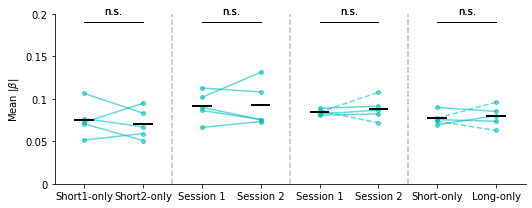

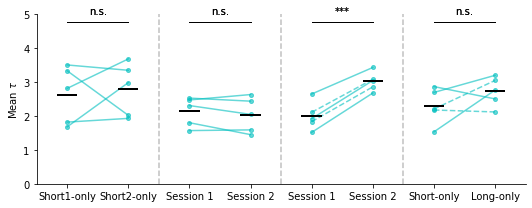

In [4]:
# Process both datasets
data_dir2 = 'C:\\Users\Eva\Desktop\imaging250429'
n_back = 15

# Lists to store correlations for each session pair
session_tau_correlations = []
session_beta_correlations = []

# Process long-to-short data
data_dir_long_to_short = 'C:\\Users\Eva\Desktop\imaging250429\matching\long_to_short_RSC'
(median_tau_list_long_to_short, median_abs_beta_list_long_to_short, 
 all_tau_pairs_short_long_to_short, all_tau_pairs_long_long_to_short, 
 all_beta_pairs_short_long_to_short, all_beta_pairs_long_long_to_short,
 all_short_only_tau_long_to_short, all_short_only_beta_long_to_short,
 all_long_only_tau_long_to_short, all_long_only_beta_long_to_short,
 median_tau_short_only_list_long_to_short, median_tau_long_only_list_long_to_short,
 median_abs_beta_short_only_list_long_to_short, median_abs_beta_long_only_list_long_to_short) = process_data(
    data_dir_long_to_short, data_dir2, n_back, is_long_to_short=True)

# Process short-to-long data
data_dir_short_to_long = 'C:\\Users\Eva\Desktop\imaging250429\matching\short_to_long_RSC'
(median_tau_list_short_to_long, median_abs_beta_list_short_to_long, 
 all_tau_pairs_short_short_to_long, all_tau_pairs_long_short_to_long, 
 all_beta_pairs_short_short_to_long, all_beta_pairs_long_short_to_long,
 all_short_only_tau_short_to_long, all_short_only_beta_short_to_long,
 all_long_only_tau_short_to_long, all_long_only_beta_short_to_long,
 median_tau_short_only_list_short_to_long, median_tau_long_only_list_short_to_long,
 median_abs_beta_short_only_list_short_to_long, median_abs_beta_long_only_list_short_to_long) = process_data(
    data_dir_short_to_long, data_dir2, n_back, is_long_to_short=False)

# Process short-to-short data
data_dir_short_to_short = 'C:\\Users\Eva\Desktop\imaging250429\matching\short_to_short_RSC'
(median_tau_list_short_to_short, median_abs_beta_list_short_to_short, 
 all_tau_pairs_short_to_short1, all_tau_pairs_short_to_short2, 
 all_beta_pairs_short_to_short1, all_beta_pairs_short_to_short2,
 all_short1_only_tau_ss, all_short1_only_beta_ss,
 all_short2_only_tau_ss, all_short2_only_beta_ss,
 median_tau_short1_only_list_ss, median_tau_short2_only_list_ss,
 median_abs_beta_short1_only_list_ss, median_abs_beta_short2_only_list_ss) = process_short_to_short_data(
    data_dir_short_to_short, data_dir2, n_back)

# Calculate short-to-short correlations
short_to_short_tau_correlations = []
short_to_short_beta_correlations = []

for i in range(len(all_tau_pairs_short_to_short1)):
    tau_corr = stats.spearmanr(all_tau_pairs_short_to_short1[i], all_tau_pairs_short_to_short2[i])
    beta_corr = stats.spearmanr(np.abs(all_beta_pairs_short_to_short1[i]), np.abs(all_beta_pairs_short_to_short2[i]))
    short_to_short_tau_correlations.append(tau_corr)
    short_to_short_beta_correlations.append(beta_corr)


# Create lists for boxplots
# For tau values
short_taus = []
long_taus = []

# From long-to-short transitions (flipped to match task type)
for pair in median_tau_list_long_to_short:
    short_taus.append(pair[1])  # Second session is short
    long_taus.append(pair[0])   # First session is long

# From short-to-long transitions
for pair in median_tau_list_short_to_long:
    short_taus.append(pair[0])  # First session is short
    long_taus.append(pair[1])   # Second session is long

# For beta values
short_betas = []
long_betas = []

# From long-to-short transitions (flipped to match task type)
for pair in median_abs_beta_list_long_to_short:
    short_betas.append(pair[1])  # Second session is short
    long_betas.append(pair[0])   # First session is long

# From short-to-long transitions
for pair in median_abs_beta_list_short_to_long:
    short_betas.append(pair[0])  # First session is short
    long_betas.append(pair[1])   # Second session is long

# Set manual y-axis limits
tau_ylim = [0, 5]
beta_ylim = [0, 0.2]

# Prepare for statistical analysis by grouping data by mouse
mouse_tau_first = {}
mouse_tau_second = {}
mouse_beta_first = {}
mouse_beta_second = {}

# Get lists of files for both datasets
os.chdir(data_dir_long_to_short)
list_of_files_long_to_short = glob.glob('*.mat')

os.chdir(data_dir_short_to_long)
list_of_files_short_to_long = glob.glob('*.mat')

# Process pairs for tau and beta, tracking the mouse for each pair
for i, pair in enumerate(median_tau_list_long_to_short):
    mouse = list_of_files_long_to_short[i][0:5]  # Extract mouse ID from filename
    if mouse not in mouse_tau_first:
        mouse_tau_first[mouse] = []
        mouse_tau_second[mouse] = []
    mouse_tau_first[mouse].append(pair[0])
    mouse_tau_second[mouse].append(pair[1])

for i, pair in enumerate(median_abs_beta_list_long_to_short):
    mouse = list_of_files_long_to_short[i][0:5]  # Extract mouse ID from filename
    if mouse not in mouse_beta_first:
        mouse_beta_first[mouse] = []
        mouse_beta_second[mouse] = []
    mouse_beta_first[mouse].append(pair[0])
    mouse_beta_second[mouse].append(pair[1])

# Short-to-long data
for i, pair in enumerate(median_tau_list_short_to_long):
    mouse = list_of_files_short_to_long[i][0:5]  # Extract mouse ID from filename
    if mouse not in mouse_tau_first:
        mouse_tau_first[mouse] = []
        mouse_tau_second[mouse] = []
    mouse_tau_first[mouse].append(pair[0])
    mouse_tau_second[mouse].append(pair[1])

for i, pair in enumerate(median_abs_beta_list_short_to_long):
    mouse = list_of_files_short_to_long[i][0:5]  # Extract mouse ID from filename
    if mouse not in mouse_beta_first:
        mouse_beta_first[mouse] = []
        mouse_beta_second[mouse] = []
    mouse_beta_first[mouse].append(pair[0])
    mouse_beta_second[mouse].append(pair[1])

# Prepare data for mixed-effects model using raw data points
tau_data = []
beta_data = []

# Create data for mixed models using raw data points
for mouse in mouse_tau_first:
    for value in mouse_tau_first[mouse]:
        tau_data.append({
        'mouse': mouse,
        'session': 'First',
            'value': value
    })
    for value in mouse_tau_second[mouse]:
        tau_data.append({
        'mouse': mouse,
        'session': 'Second',
            'value': value
    })

for mouse in mouse_beta_first:
    for value in mouse_beta_first[mouse]:
        beta_data.append({
        'mouse': mouse,
        'session': 'First',
            'value': value
    })
    for value in mouse_beta_second[mouse]:
        beta_data.append({
            'mouse': mouse,
            'session': 'Second',
            'value': value
        })

# Convert to pandas DataFrames
tau_df = pd.DataFrame(tau_data)
beta_df = pd.DataFrame(beta_data)

# Run mixed-effects models
# Tau model
tau_model = sm.MixedLM.from_formula(
    "value ~ session", 
    groups=tau_df["mouse"], 
    data=tau_df
)
tau_fit = tau_model.fit()
print("\nMixed-effects model for tau (using raw data points):")
print(tau_fit.summary())
print("Model includes random intercept for each mouse")

# Get p-value for session effect
tau_p_value = tau_fit.pvalues['session[T.Second]']

# Beta model
beta_model = sm.MixedLM.from_formula(
    "value ~ session", 
    groups=beta_df["mouse"], 
    data=beta_df
)
beta_fit = beta_model.fit()
print("\nMixed-effects model for beta (using raw data points):")
print(beta_fit.summary())
print("Model includes random intercept for each mouse")

# Get p-value for session effect
beta_p_value = beta_fit.pvalues['session[T.Second]']

print(f"\nMixed-effects model results (using raw data points):")
print(f"Tau first vs second session: p = {tau_p_value:.6f}")
print(f"Beta first vs second session: p = {beta_p_value:.6f}")

# Prepare for short-to-short statistical analysis
mouse_tau_first_ss = {}
mouse_tau_second_ss = {}
mouse_beta_first_ss = {}
mouse_beta_second_ss = {}

# Get list of files for short-to-short data
os.chdir(data_dir_short_to_short)
list_of_files_short_to_short = glob.glob('*.mat')

# Process pairs for tau and beta, tracking the mouse for each pair
for i, pair in enumerate(median_tau_list_short_to_short):
    mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID from filename
    if mouse not in mouse_tau_first_ss:
        mouse_tau_first_ss[mouse] = []
        mouse_tau_second_ss[mouse] = []
    mouse_tau_first_ss[mouse].append(pair[0])
    mouse_tau_second_ss[mouse].append(pair[1])

for i, pair in enumerate(median_abs_beta_list_short_to_short):
    mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID from filename
    if mouse not in mouse_beta_first_ss:
        mouse_beta_first_ss[mouse] = []
        mouse_beta_second_ss[mouse] = []
    mouse_beta_first_ss[mouse].append(pair[0])
    mouse_beta_second_ss[mouse].append(pair[1])

# Prepare data for mixed-effects model using raw data points
tau_data_ss = []
beta_data_ss = []

# Create data for mixed models using raw data points
for mouse in mouse_tau_first_ss:
    for value in mouse_tau_first_ss[mouse]:
        tau_data_ss.append({
            'mouse': mouse,
            'session': 'First',
            'value': value
        })
    for value in mouse_tau_second_ss[mouse]:
        tau_data_ss.append({
            'mouse': mouse,
            'session': 'Second',
            'value': value
        })

for mouse in mouse_beta_first_ss:
    for value in mouse_beta_first_ss[mouse]:
        beta_data_ss.append({
            'mouse': mouse,
            'session': 'First',
            'value': value
        })
    for value in mouse_beta_second_ss[mouse]:
        beta_data_ss.append({
            'mouse': mouse,
            'session': 'Second',
            'value': value
        })

# Convert to pandas DataFrames
tau_df_ss = pd.DataFrame(tau_data_ss)
beta_df_ss = pd.DataFrame(beta_data_ss)

# Run mixed-effects models for short-to-short comparisons
# Tau model
tau_model_ss = sm.MixedLM.from_formula(
    "value ~ session", 
    groups=tau_df_ss["mouse"], 
    data=tau_df_ss
)
tau_fit_ss = tau_model_ss.fit()
print("\nMixed-effects model for short-to-short tau (using raw data points):")
print(tau_fit_ss.summary())
print("Model includes random intercept for each mouse")

# Get p-value for session effect
tau_p_value_ss = tau_fit_ss.pvalues['session[T.Second]']

# Beta model
beta_model_ss = sm.MixedLM.from_formula(
    "value ~ session", 
    groups=beta_df_ss["mouse"], 
    data=beta_df_ss
)
beta_fit_ss = beta_model_ss.fit()
print("\nMixed-effects model for short-to-short beta (using raw data points):")
print(beta_fit_ss.summary())
print("Model includes random intercept for each mouse")

# Get p-value for session effect
beta_p_value_ss = beta_fit_ss.pvalues['session[T.Second]']

print(f"\nShort-to-Short mixed-effects model results (using raw data points):")
print(f"Tau first vs second session: p = {tau_p_value_ss:.6f}")
print(f"Beta first vs second session: p = {beta_p_value_ss:.6f}")

# Create combined figure for tau comparisons
fig_tau_combined, ax_tau_combined = plt.subplots(1, 1, figsize=(7.5, 3))

# Define x-axis positions for all 8 columns
x_positions = [1, 2, 3, 4, 5, 6, 7, 8]

# Plot and connect short-to-short session pairs for non-overlapped cells - NOW COLUMNS 1 & 2
for i, (short1_value, short2_value) in enumerate(zip(median_tau_short1_only_list_ss, median_tau_short2_only_list_ss)):
    if not np.isnan(short1_value) and not np.isnan(short2_value):
        ax_tau_combined.plot([1, 2], [short1_value, short2_value], marker='o', color=plt_colors['RSC'], alpha=0.6,
                label='Short→Short Non-overlapping' if i == 0 else "",
                linestyle='-', markersize=4)

# Plot short-to-short tau data - NOW COLUMNS 3 & 4
for i, pair in enumerate(median_tau_list_short_to_short):
    ax_tau_combined.plot([3, 4], pair, marker='o', color=plt_colors['RSC'], alpha=0.6,
            label='Short → Short Overlapping' if i == 0 else "",
            linestyle='-', markersize=4)

# Plot across-task tau data - NOW COLUMNS 5 & 6
for i, pair in enumerate(median_tau_list_long_to_short):
    ax_tau_combined.plot([5, 6], pair, marker='o', color=plt_colors['RSC'], alpha=0.6, 
            label='Long → Short' if i == 0 else "",
            linestyle='-', markersize=4)

# Plot short-to-long data for tau - NOW COLUMNS 5 & 6
for i, pair in enumerate(median_tau_list_short_to_long):
    ax_tau_combined.plot([5, 6], pair, marker='o', color=plt_colors['RSC'], alpha=0.6,
            label='Short → Long' if i == 0 else "",
            linestyle='--', markersize=4)

# Plot and connect long-to-short session pairs for non-overlapped cells - NOW COLUMNS 7 & 8
for i, (short_value, long_value) in enumerate(zip(median_tau_short_only_list_long_to_short, median_tau_long_only_list_long_to_short)):
    if not np.isnan(short_value) and not np.isnan(long_value):
        ax_tau_combined.plot([7, 8], [short_value, long_value], marker='o', color=plt_colors['RSC'], alpha=0.6,
                label='Long→Short Non-overlapping' if i == 0 else "",
                linestyle='-', markersize=4)

# Plot and connect short-to-long session pairs for non-overlapped cells - NOW COLUMNS 7 & 8
for i, (short_value, long_value) in enumerate(zip(median_tau_short_only_list_short_to_long, median_tau_long_only_list_short_to_long)):
    if not np.isnan(short_value) and not np.isnan(long_value):
        ax_tau_combined.plot([7, 8], [short_value, long_value], marker='o', color=plt_colors['RSC'], alpha=0.6,
                label='Short→Long Non-overlapping' if i == 0 else "",
                linestyle='--', markersize=4)

# Calculate and plot mean values for all groups
# Short-to-short non-overlapping (columns 1 & 2) 
short_to_short_short1_only = [x for x in median_tau_short1_only_list_ss if not np.isnan(x)]
short_to_short_short2_only = [x for x in median_tau_short2_only_list_ss if not np.isnan(x)]
tau_short1_only_mean_ss = np.mean(short_to_short_short1_only)
tau_short2_only_mean_ss = np.mean(short_to_short_short2_only)
ax_tau_combined.plot([0.85, 1.15], [tau_short1_only_mean_ss, tau_short1_only_mean_ss], 'k-', linewidth=2)
ax_tau_combined.plot([1.85, 2.15], [tau_short2_only_mean_ss, tau_short2_only_mean_ss], 'k-', linewidth=2)

# Short-to-short overlapping (columns 3 & 4)
tau_first_mean_ss = np.mean([pair[0] for pair in median_tau_list_short_to_short])
tau_second_mean_ss = np.mean([pair[1] for pair in median_tau_list_short_to_short])
ax_tau_combined.plot([2.85, 3.15], [tau_first_mean_ss, tau_first_mean_ss], 'k-', linewidth=2)
ax_tau_combined.plot([3.85, 4.15], [tau_second_mean_ss, tau_second_mean_ss], 'k-', linewidth=2)

# Across-task overlapping (columns 5 & 6)
first_session_taus = [pair[0] for pair in median_tau_list_long_to_short + median_tau_list_short_to_long]
second_session_taus = [pair[1] for pair in median_tau_list_long_to_short + median_tau_list_short_to_long]
tau_first_mean = np.mean(first_session_taus)
tau_second_mean = np.mean(second_session_taus)
ax_tau_combined.plot([4.85, 5.15], [tau_first_mean, tau_first_mean], 'k-', linewidth=2)
ax_tau_combined.plot([5.85, 6.15], [tau_second_mean, tau_second_mean], 'k-', linewidth=2)

# Across-task non-overlapping (columns 7 & 8)
long_to_short_short_only = [x for x in median_tau_short_only_list_long_to_short if not np.isnan(x)]
long_to_short_long_only = [x for x in median_tau_long_only_list_long_to_short if not np.isnan(x)]
short_to_long_short_only = [x for x in median_tau_short_only_list_short_to_long if not np.isnan(x)]
short_to_long_long_only = [x for x in median_tau_long_only_list_short_to_long if not np.isnan(x)]
tau_short_only_mean = np.mean(long_to_short_short_only + short_to_long_short_only)
tau_long_only_mean = np.mean(long_to_short_long_only + short_to_long_long_only)
ax_tau_combined.plot([6.85, 7.15], [tau_short_only_mean, tau_short_only_mean], 'k-', linewidth=2)
ax_tau_combined.plot([7.85, 8.15], [tau_long_only_mean, tau_long_only_mean], 'k-', linewidth=2)

# Add significance indicators

# 1. Short-to-short non-overlapping (columns 1 & 2)
print("\nRunning mixed-effects model for short-to-short non-overlapping (columns 1 & 2):")
col1_vs_col2_data = []
for i, (short1_value, short2_value) in enumerate(zip(median_tau_short1_only_list_ss, median_tau_short2_only_list_ss)):
    if not np.isnan(short1_value) and not np.isnan(short2_value):
        mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
        col1_vs_col2_data.append({
            'mouse': mouse,
            'session': 'Session1',
            'value': short1_value
        })
        col1_vs_col2_data.append({
            'mouse': mouse,
            'session': 'Session2',
            'value': short2_value
        })

col1_vs_col2_df = pd.DataFrame(col1_vs_col2_data)
if len(col1_vs_col2_df) > 0:
    try:
        col1_vs_col2_model = sm.MixedLM.from_formula(
            "value ~ session", 
            groups=col1_vs_col2_df["mouse"],
            data=col1_vs_col2_df
        )
        col1_vs_col2_fit = col1_vs_col2_model.fit()
        print(col1_vs_col2_fit.summary())
        
        # Extract p-value
        p_val_ss = col1_vs_col2_fit.pvalues.get('session[T.Session2]')
        print(f"\nP-value for short-to-short non-overlapping: {p_val_ss:.6f}")
        
        # Determine significance
        sig_text_ss = "n.s."
        if p_val_ss < 0.001:
            sig_text_ss = "***"
        elif p_val_ss < 0.01:
            sig_text_ss = "**"
        elif p_val_ss < 0.05:
            sig_text_ss = "*"
    except Exception as e:
        print(f"Error in mixed-effects model for short-to-short non-overlapping: {e}")
        sig_text_ss = "n.s."
else:
    print("Insufficient data for mixed-effects model on short-to-short non-overlapping neurons.")
    sig_text_ss = "n.s."

bar_height = tau_ylim[1] * 0.95
ax_tau_combined.plot([1, 2], [bar_height, bar_height], 'k-', linewidth=1)
ax_tau_combined.text(1.5, bar_height * 1.05, sig_text_ss, ha='center', fontsize=10)

# 2. Short-to-short overlapping (columns 3 & 4)
p_val = tau_p_value_ss
sig_text_ss = "n.s."
if p_val < 0.001:
    sig_text_ss = "***"
elif p_val < 0.01:
    sig_text_ss = "**"
elif p_val < 0.05:
    sig_text_ss = "*"
bar_height = tau_ylim[1] * 0.95
ax_tau_combined.plot([3, 4], [bar_height, bar_height], 'k-', linewidth=1)
ax_tau_combined.text(3.5, bar_height * 1.05, sig_text_ss, ha='center', fontsize=10)

# 3. Across-task overlapping (columns 5 & 6)
p_val = tau_p_value
sig_text_at = "n.s."
if p_val < 0.001:
    sig_text_at = "***"
elif p_val < 0.01:
    sig_text_at = "**"
elif p_val < 0.05:
    sig_text_at = "*"
bar_height = tau_ylim[1] * 0.95
ax_tau_combined.plot([5, 6], [bar_height, bar_height], 'k-', linewidth=1)
ax_tau_combined.text(5.5, bar_height * 1.05, sig_text_at, ha='center', fontsize=10)

# 4. Across-task non-overlapping (columns 7 & 8)
print("\nRunning mixed-effects model for across-task non-overlapping (columns 7 & 8):")
col7_vs_col8_data = []

# Get appropriate file lists
os.chdir(data_dir_long_to_short)
list_of_files_long_to_short = glob.glob('*.mat')
os.chdir(data_dir_short_to_long)
list_of_files_short_to_long = glob.glob('*.mat')

# Long-to-short data
for i, (short_value, long_value) in enumerate(zip(median_tau_short_only_list_long_to_short, median_tau_long_only_list_long_to_short)):
    if not np.isnan(short_value) and not np.isnan(long_value):
        mouse = list_of_files_long_to_short[i][0:5]  # Extract mouse ID
        col7_vs_col8_data.append({
            'mouse': mouse,
            'session': 'Short',
            'value': short_value
        })
        col7_vs_col8_data.append({
            'mouse': mouse,
            'session': 'Long',
            'value': long_value
        })

# Short-to-long data
for i, (short_value, long_value) in enumerate(zip(median_tau_short_only_list_short_to_long, median_tau_long_only_list_short_to_long)):
    if not np.isnan(short_value) and not np.isnan(long_value):
        mouse = list_of_files_short_to_long[i][0:5]  # Extract mouse ID
        col7_vs_col8_data.append({
            'mouse': mouse,
            'session': 'Short',
            'value': short_value
        })
        col7_vs_col8_data.append({
            'mouse': mouse,
            'session': 'Long',
            'value': long_value
        })

col7_vs_col8_df = pd.DataFrame(col7_vs_col8_data)
if len(col7_vs_col8_df) > 0:
    try:
        col7_vs_col8_model = sm.MixedLM.from_formula(
            "value ~ session", 
            groups=col7_vs_col8_df["mouse"],
            data=col7_vs_col8_df)
        col7_vs_col8_results = col7_vs_col8_model.fit()
        p_val = col7_vs_col8_results.pvalues['session']
        
        if p_val < 0.001:
            sig_text = "***"
        elif p_val < 0.01:
            sig_text = "**"
        elif p_val < 0.05:
            sig_text = "*"
        else:
            sig_text = "n.s."
    except Exception as e:
        print(f"Error in mixed-effects model for across-task non-overlapping: {e}")
        sig_text = "n.s."
else:
    print("Insufficient data for mixed-effects model on across-task non-overlapping neurons.")
    
bar_height = tau_ylim[1] * 0.95
ax_tau_combined.plot([7, 8], [bar_height, bar_height], 'k-', linewidth=1)
ax_tau_combined.text(7.5, bar_height * 1.05, sig_text, ha='center', fontsize=10)

# Update the statistical comparison for columns 1 and 3 (formerly 7 and 1)
# This is now comparing short1-only non-overlapping with overlapping first session
# Check if the variable exists, and if not, create it with a default value
if 'p_value_col1_vs_col7' not in locals() or 'sig_text_col1_vs_col7' not in locals():
    print("Running comparison between columns 1 and 3 (short1-only vs overlapping first session)")
    # Create a new dataframe for this comparison
    col1_vs_col3_data = []
    
    # Add data from column 1 (short1-only non-overlapping)
    for i, value in enumerate(median_tau_short1_only_list_ss):
        if not np.isnan(value):
            mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
            col1_vs_col3_data.append({
                'mouse': mouse,
                'group': 'Non-overlapping',
                'value': value
            })
    
    # Add data from column 3 (overlapping first session)
    for i, pair in enumerate(median_tau_list_short_to_short):
        mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
        col1_vs_col3_data.append({
            'mouse': mouse,
            'group': 'Overlapping',
            'value': pair[0]  # First session tau
        })
    
    # Convert to DataFrame
    col1_vs_col3_df = pd.DataFrame(col1_vs_col3_data)
    
    # Run mixed-effects model
    if len(col1_vs_col3_df) > 0:
        try:
            col1_vs_col3_model = sm.MixedLM.from_formula(
                "value ~ group", 
                groups=col1_vs_col3_df["mouse"],
                data=col1_vs_col3_df
            )
            col1_vs_col3_fit = col1_vs_col3_model.fit()
            print(col1_vs_col3_fit.summary())
            
            # Extract p-value
            p_value_col1_vs_col7 = col1_vs_col3_fit.pvalues.get('group[T.Overlapping]', 
                                                             col1_vs_col3_fit.pvalues.get('group[T.Non-overlapping]'))
            print(f"\nP-value for difference between short1-only and overlapping (first session): {p_value_col1_vs_col7:.6f}")
            
            # Determine significance
            sig_text_col1_vs_col7 = "n.s."
            if p_value_col1_vs_col7 < 0.001:
                sig_text_col1_vs_col7 = "***"
            elif p_value_col1_vs_col7 < 0.01:
                sig_text_col1_vs_col7 = "**"
            elif p_value_col1_vs_col7 < 0.05:
                sig_text_col1_vs_col7 = "*"
                
            # Calculate means for reference
            mean_overlapping = col1_vs_col3_df[col1_vs_col3_df['group'] == 'Overlapping']['value'].mean()
            mean_non_overlapping = col1_vs_col3_df[col1_vs_col3_df['group'] == 'Non-overlapping']['value'].mean()
            print(f"Mean tau for overlapping neurons (first session): {mean_overlapping:.3f}")
            print(f"Mean tau for non-overlapping neurons (short1-only): {mean_non_overlapping:.3f}")
            
        except Exception as e:
            print(f"Error running mixed-effects model for columns 1 vs 3: {e}")
            sig_text_col1_vs_col7 = "n.s."
    else:
        print("Insufficient data for mixed-effects model comparing columns 1 and 3.")
        sig_text_col1_vs_col7 = "n.s."

# bar_height = tau_ylim[1] * 1.15
# ax_tau_combined.plot([1, 3], [bar_height, bar_height], 'k-', linewidth=1)
# ax_tau_combined.text(2, bar_height * 1.05, sig_text_col1_vs_col7, ha='center', fontsize=10)

# Update the statistical comparison for columns 2 and 4 (formerly 8 and 2)
# This is now comparing short2-only non-overlapping with overlapping second session
# Check if the variable exists, and if not, create it with a default value
if 'p_value_col2_vs_col8' not in locals() or 'sig_text_col2_vs_col8' not in locals():
    print("Running comparison between columns 2 and 4 (short2-only vs overlapping second session)")
    # Create a new dataframe for this comparison
    col2_vs_col4_data = []
    
    # Add data from column 2 (short2-only non-overlapping)
    for i, value in enumerate(median_tau_short2_only_list_ss):
        if not np.isnan(value):
            mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
            col2_vs_col4_data.append({
                'mouse': mouse,
                'group': 'Non-overlapping',
                'value': value
            })
    
    # Add data from column 4 (overlapping second session)
    for i, pair in enumerate(median_tau_list_short_to_short):
        mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
        col2_vs_col4_data.append({
            'mouse': mouse,
            'group': 'Overlapping',
            'value': pair[1]  # Second session tau
        })
    
    # Convert to DataFrame
    col2_vs_col4_df = pd.DataFrame(col2_vs_col4_data)

# Run mixed-effects model
    if len(col2_vs_col4_df) > 0:
        try:
            col2_vs_col4_model = sm.MixedLM.from_formula(
                "value ~ group", 
                groups=col2_vs_col4_df["mouse"],
                data=col2_vs_col4_df
            )
            col2_vs_col4_fit = col2_vs_col4_model.fit()
            print(col2_vs_col4_fit.summary())
            
            # Extract p-value
            p_value_col2_vs_col8 = col2_vs_col4_fit.pvalues.get('group[T.Overlapping]', 
                                                             col2_vs_col4_fit.pvalues.get('group[T.Non-overlapping]'))
            print(f"\nP-value for difference between short2-only and overlapping (second session): {p_value_col2_vs_col8:.6f}")
            
            # Determine significance
            sig_text_col2_vs_col8 = "n.s."
            if p_value_col2_vs_col8 < 0.001:
                sig_text_col2_vs_col8 = "***"
            elif p_value_col2_vs_col8 < 0.01:
                sig_text_col2_vs_col8 = "**"
            elif p_value_col2_vs_col8 < 0.05:
                sig_text_col2_vs_col8 = "*"
                
            # Calculate means for reference
            mean_overlapping = col2_vs_col4_df[col2_vs_col4_df['group'] == 'Overlapping']['value'].mean()
            mean_non_overlapping = col2_vs_col4_df[col2_vs_col4_df['group'] == 'Non-overlapping']['value'].mean()
            print(f"Mean tau for overlapping neurons (second session): {mean_overlapping:.3f}")
            print(f"Mean tau for non-overlapping neurons (short2-only): {mean_non_overlapping:.3f}")
            
        except Exception as e:
            print(f"Error running mixed-effects model for columns 2 vs 4: {e}")
            sig_text_col2_vs_col8 = "n.s."
else:
        print("Insufficient data for mixed-effects model comparing columns 2 and 4.")
        sig_text_col2_vs_col8 = "n.s."

# bar_height = tau_ylim[1] * 1.25
# ax_tau_combined.plot([2, 4], [bar_height, bar_height], 'k-', linewidth=1)
# ax_tau_combined.text(3, bar_height * 1.05, sig_text_col2_vs_col8, ha='center', fontsize=10)

ax_tau_combined.set_xticks(x_positions)
ax_tau_combined.set_xticklabels(['Short1-only', 'Short2-only', 'Session 1', 'Session 2', 'Session 1', 'Session 2', 'Short-only', 'Long-only'], fontsize=10)
ax_tau_combined.spines['top'].set_visible(False)
ax_tau_combined.spines['right'].set_visible(False)
ax_tau_combined.set_xlim([0.5, 8.5])
ax_tau_combined.set_ylim(tau_ylim)
ax_tau_combined.set_ylabel('Mean $\\tau$', fontsize=10)
# ax_tau_combined.legend(fontsize=8, frameon=False, loc='upper left')

# Add vertical lines to separate different comparisons
ax_tau_combined.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5)
ax_tau_combined.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5)
ax_tau_combined.axvline(x=6.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save the updated plot
plt.savefig(pjoin(save_dir, 'tau_combined_comparison.png'), dpi=300, bbox_inches='tight')
plt.savefig(pjoin(save_dir, 'tau_combined_comparison.svg'), format='svg', bbox_inches='tight')

# Print median tau values for each session pair
print("\nMedian tau values from short-only and long-only populations:")
print("\nLong-to-Short transitions:")
os.chdir(data_dir_long_to_short)
list_of_files_long_to_short = glob.glob('*.mat')
for i, (short_value, long_value, file) in enumerate(zip(median_tau_short_only_list_long_to_short, median_tau_long_only_list_long_to_short, list_of_files_long_to_short)):
    if not np.isnan(short_value) and not np.isnan(long_value):
        mouse = file[0:5]
        area = file[20:-4]
        date1 = file[6:12]
        date2 = file[13:19]
        print(f"Session pair {i+1} ({area}):")
        print(f"  {mouse}_{date1} (Long) → {mouse}_{date2} (Short)")
        print(f"  Short-only median tau: {short_value:.3f}")
        print(f"  Long-only median tau: {long_value:.3f}")

print("\nShort-to-Long transitions:")
os.chdir(data_dir_short_to_long)
list_of_files_short_to_long = glob.glob('*.mat')
for i, (short_value, long_value, file) in enumerate(zip(median_tau_short_only_list_short_to_long, median_tau_long_only_list_short_to_long, list_of_files_short_to_long)):
    if not np.isnan(short_value) and not np.isnan(long_value):
        mouse = file[0:5]
        area = file[20:-4]
        date1 = file[6:12]
        date2 = file[13:19]
        print(f"Session pair {i+1} ({area}):")
        print(f"  {mouse}_{date1} (Short) → {mouse}_{date2} (Long)")
        print(f"  Short-only median tau: {short_value:.3f}")
        print(f"  Long-only median tau: {long_value:.3f}")

# Create combined figure for beta comparisons
fig_beta_combined, ax_beta_combined = plt.subplots(1, 1, figsize=(7.5, 3))

# Define x-axis positions for all 8 columns
x_positions = [1, 2, 3, 4, 5, 6, 7, 8]

# Plot and connect short-to-short session pairs for non-overlapped cells (beta) - NOW COLUMNS 1 & 2
for i, (short1_value, short2_value) in enumerate(zip(median_abs_beta_short1_only_list_ss, median_abs_beta_short2_only_list_ss)):
    if not np.isnan(short1_value) and not np.isnan(short2_value):
        ax_beta_combined.plot([1, 2], [short1_value, short2_value], marker='o', color=plt_colors['RSC'], alpha=0.6,
                label='Short→Short Non-overlapping' if i == 0 else "",
                linestyle='-', markersize=4)

# Plot short-to-short beta data - NOW COLUMNS 3 & 4
for i, pair in enumerate(median_abs_beta_list_short_to_short):
    ax_beta_combined.plot([3, 4], pair, marker='o', color=plt_colors['RSC'], alpha=0.6,
            label='Short → Short Overlapping' if i == 0 else "",
            linestyle='-', markersize=4)

# Plot across-task beta data - NOW COLUMNS 5 & 6
for i, pair in enumerate(median_abs_beta_list_long_to_short):
    ax_beta_combined.plot([5, 6], pair, marker='o', color=plt_colors['RSC'], alpha=0.6, 
            label='Long → Short' if i == 0 else "",
            linestyle='-', markersize=4)

# Plot short-to-long data for beta - NOW COLUMNS 5 & 6
for i, pair in enumerate(median_abs_beta_list_short_to_long):
    ax_beta_combined.plot([5, 6], pair, marker='o', color=plt_colors['RSC'], alpha=0.6,
            label='Short → Long' if i == 0 else "",
            linestyle='--', markersize=4)

# Plot and connect long-to-short session pairs for non-overlapped cells - NOW COLUMNS 7 & 8
for i, (short_value, long_value) in enumerate(zip(median_abs_beta_short_only_list_long_to_short, median_abs_beta_long_only_list_long_to_short)):
    if not np.isnan(short_value) and not np.isnan(long_value):
        ax_beta_combined.plot([7, 8], [short_value, long_value], marker='o', color=plt_colors['RSC'], alpha=0.6,
                label='Long→Short Non-overlapping' if i == 0 else "",
                linestyle='-', markersize=4)

# Plot and connect short-to-long session pairs for non-overlapped cells - NOW COLUMNS 7 & 8
for i, (short_value, long_value) in enumerate(zip(median_abs_beta_short_only_list_short_to_long, median_abs_beta_long_only_list_short_to_long)):
    if not np.isnan(short_value) and not np.isnan(long_value):
        ax_beta_combined.plot([7, 8], [short_value, long_value], marker='o', color=plt_colors['RSC'], alpha=0.6,
                label='Short→Long Non-overlapping' if i == 0 else "",
                linestyle='--', markersize=4)

# Calculate and plot mean values for all groups
# Short-to-short non-overlapping (columns 1 & 2)
short_to_short_short1_only_beta = [x for x in median_abs_beta_short1_only_list_ss if not np.isnan(x)]
short_to_short_short2_only_beta = [x for x in median_abs_beta_short2_only_list_ss if not np.isnan(x)]
beta_short1_only_mean_ss = np.mean(short_to_short_short1_only_beta)
beta_short2_only_mean_ss = np.mean(short_to_short_short2_only_beta)
ax_beta_combined.plot([0.85, 1.15], [beta_short1_only_mean_ss, beta_short1_only_mean_ss], 'k-', linewidth=2)
ax_beta_combined.plot([1.85, 2.15], [beta_short2_only_mean_ss, beta_short2_only_mean_ss], 'k-', linewidth=2)

# Short-to-short overlapping (columns 3 & 4)
beta_first_mean_ss = np.mean([pair[0] for pair in median_abs_beta_list_short_to_short])
beta_second_mean_ss = np.mean([pair[1] for pair in median_abs_beta_list_short_to_short])
ax_beta_combined.plot([2.85, 3.15], [beta_first_mean_ss, beta_first_mean_ss], 'k-', linewidth=2)
ax_beta_combined.plot([3.85, 4.15], [beta_second_mean_ss, beta_second_mean_ss], 'k-', linewidth=2)

# Across-task overlapping (columns 5 & 6)
first_session_betas = [pair[0] for pair in median_abs_beta_list_long_to_short + median_abs_beta_list_short_to_long]
second_session_betas = [pair[1] for pair in median_abs_beta_list_long_to_short + median_abs_beta_list_short_to_long]
beta_first_mean = np.mean(first_session_betas)
beta_second_mean = np.mean(second_session_betas)
ax_beta_combined.plot([4.85, 5.15], [beta_first_mean, beta_first_mean], 'k-', linewidth=2)
ax_beta_combined.plot([5.85, 6.15], [beta_second_mean, beta_second_mean], 'k-', linewidth=2)

# Across-task non-overlapping (columns 7 & 8)
long_to_short_short_only_beta = [x for x in median_abs_beta_short_only_list_long_to_short if not np.isnan(x)]
long_to_short_long_only_beta = [x for x in median_abs_beta_long_only_list_long_to_short if not np.isnan(x)]
short_to_long_short_only_beta = [x for x in median_abs_beta_short_only_list_short_to_long if not np.isnan(x)]
short_to_long_long_only_beta = [x for x in median_abs_beta_long_only_list_short_to_long if not np.isnan(x)]
beta_short_only_mean = np.mean(long_to_short_short_only_beta + short_to_long_short_only_beta)
beta_long_only_mean = np.mean(long_to_short_long_only_beta + short_to_long_long_only_beta)
ax_beta_combined.plot([6.85, 7.15], [beta_short_only_mean, beta_short_only_mean], 'k-', linewidth=2)
ax_beta_combined.plot([7.85, 8.15], [beta_long_only_mean, beta_long_only_mean], 'k-', linewidth=2)

# Add significance indicators

# 1. Short-to-short non-overlapping (columns 1 & 2)
stat_ss_beta, p_val_ss_beta = mannwhitneyu(short_to_short_short1_only_beta, short_to_short_short2_only_beta)
sig_text_ss_beta = "n.s."
if p_val_ss_beta < 0.001:
    sig_text_ss_beta = "***"
elif p_val_ss_beta < 0.01:
    sig_text_ss_beta = "**"
elif p_val_ss_beta < 0.05:
    sig_text_ss_beta = "*"
bar_height = beta_ylim[1] * 0.95
ax_beta_combined.plot([1, 2], [bar_height, bar_height], 'k-', linewidth=1)
ax_beta_combined.text(1.5, bar_height * 1.05, sig_text_ss_beta, ha='center', fontsize=10)

# 2. Short-to-short overlapping (columns 3 & 4)
p_val = beta_p_value_ss
sig_text_ss = "n.s."
if p_val < 0.001:
    sig_text_ss = "***"
elif p_val < 0.01:
    sig_text_ss = "**"
elif p_val < 0.05:
    sig_text_ss = "*"
bar_height = beta_ylim[1] * 0.95
ax_beta_combined.plot([3, 4], [bar_height, bar_height], 'k-', linewidth=1)
ax_beta_combined.text(3.5, bar_height * 1.05, sig_text_ss, ha='center', fontsize=10)

# 3. Across-task overlapping (columns 5 & 6)
p_val = beta_p_value
sig_text_at = "n.s."
if p_val < 0.001:
    sig_text_at = "***"
elif p_val < 0.01:
    sig_text_at = "**"
elif p_val < 0.05:
    sig_text_at = "*"
bar_height = beta_ylim[1] * 0.95
ax_beta_combined.plot([5, 6], [bar_height, bar_height], 'k-', linewidth=1)
ax_beta_combined.text(5.5, bar_height * 1.05, sig_text_at, ha='center', fontsize=10)

# 4. Across-task non-overlapping (columns 7 & 8)
all_short_only_beta = long_to_short_short_only_beta + short_to_long_short_only_beta
all_long_only_beta = long_to_short_long_only_beta + short_to_long_long_only_beta
stat, p_val = mannwhitneyu(all_short_only_beta, all_long_only_beta)
sig_text = "n.s."
if p_val < 0.001:
    sig_text = "***"
elif p_val < 0.01:
    sig_text = "**"
elif p_val < 0.05:
    sig_text = "*"
bar_height = beta_ylim[1] * 0.95
ax_beta_combined.plot([7, 8], [bar_height, bar_height], 'k-', linewidth=1)
ax_beta_combined.text(7.5, bar_height * 1.05, sig_text, ha='center', fontsize=10)

ax_beta_combined.set_xticks(x_positions)
ax_beta_combined.set_xticklabels(['Short1-only', 'Short2-only', 'Session 1', 'Session 2', 'Session 1', 'Session 2', 'Short-only', 'Long-only'], fontsize=10)
ax_beta_combined.spines['top'].set_visible(False)
ax_beta_combined.spines['right'].set_visible(False)
ax_beta_combined.set_xlim([0.5, 8.5])
ax_beta_combined.set_ylim(beta_ylim)
ax_beta_combined.set_ylabel('Mean $|\\beta|$', fontsize=10)
ax_beta_combined.set_yticks([0, 0.05, 0.1, 0.15, 0.2])
ax_beta_combined.set_yticklabels(['0', '0.05', '0.1', '0.15', '0.2'], fontsize=10)

# Add vertical lines to separate different comparisons
ax_beta_combined.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5)
ax_beta_combined.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5)
ax_beta_combined.axvline(x=6.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save the combined plot
plt.savefig(pjoin(save_dir, 'beta_combined_comparison.png'), dpi=300, bbox_inches='tight')
plt.savefig(pjoin(save_dir, 'beta_combined_comparison.svg'), format='svg', bbox_inches='tight')

# Add mixed-effects model comparison between overlapping and non-overlapping neurons
# in the short-to-short condition (column 1 vs column 7)
print("\nRunning mixed-effects model comparing short-to-short overlapping vs. non-overlapping neurons (tau):")

# Prepare data for the model
col1_vs_col7_tau_data = []

# Get list of files for short-to-short data
os.chdir(data_dir_short_to_short)
list_of_files_short_to_short = glob.glob('*.mat')

# Add data from column 1 (overlapping neurons, first session)
for i, pair in enumerate(median_tau_list_short_to_short):
    mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
    col1_vs_col7_tau_data.append({
        'mouse': mouse,
        'group': 'Overlapping',
        'value': pair[0]  # First session tau
    })

# Add data from column 7 (non-overlapping neurons, short1-only)
for i, value in enumerate(median_tau_short1_only_list_ss):
    if not np.isnan(value):
        mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
        col1_vs_col7_tau_data.append({
            'mouse': mouse,
            'group': 'Non-overlapping',
            'value': value
        })

# Convert to DataFrame
col1_vs_col7_tau_df = pd.DataFrame(col1_vs_col7_tau_data)

# Run mixed-effects model
col1_vs_col7_tau_model = sm.MixedLM.from_formula(
    "value ~ group", 
    groups=col1_vs_col7_tau_df["mouse"],
    data=col1_vs_col7_tau_df
)

col1_vs_col7_tau_fit = col1_vs_col7_tau_model.fit()
print(col1_vs_col7_tau_fit.summary())

# Extract p-value
p_value_col1_vs_col7 = col1_vs_col7_tau_fit.pvalues.get('group[T.Overlapping]', 
                                                    col1_vs_col7_tau_fit.pvalues.get('group[T.Non-overlapping]'))
print(f"\nP-value for difference between overlapping and non-overlapping neurons (first session): {p_value_col1_vs_col7:.6f}")

# Determine significance
if p_value_col1_vs_col7 < 0.001:
    sig_text_col1_vs_col7 = "***"
elif p_value_col1_vs_col7 < 0.01:
    sig_text_col1_vs_col7 = "**"
elif p_value_col1_vs_col7 < 0.05:
    sig_text_col1_vs_col7 = "*"
else:
    sig_text_col1_vs_col7 = "n.s."
    
print(f"Significance: {sig_text_col1_vs_col7}")

# Calculate means for reference
mean_overlapping = col1_vs_col7_tau_df[col1_vs_col7_tau_df['group'] == 'Overlapping']['value'].mean()
mean_non_overlapping = col1_vs_col7_tau_df[col1_vs_col7_tau_df['group'] == 'Non-overlapping']['value'].mean()
print(f"Mean tau for overlapping neurons (first session): {mean_overlapping:.3f}")
print(f"Mean tau for non-overlapping neurons (first session): {mean_non_overlapping:.3f}")

# Add mixed-effects model comparison between overlapping and non-overlapping neurons
# in the short-to-short condition for the second session (column 2 vs column 8)
print("\nRunning mixed-effects model comparing short-to-short overlapping vs. non-overlapping neurons for second session (tau):")

# Prepare data for the model
col2_vs_col8_tau_data = []

# Add data from column 2 (overlapping neurons, second session)
for i, pair in enumerate(median_tau_list_short_to_short):
    mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
    col2_vs_col8_tau_data.append({
        'mouse': mouse,
        'group': 'Overlapping',
        'value': pair[1]  # Second session tau
    })

# Add data from column 8 (non-overlapping neurons, short2-only)
for i, value in enumerate(median_tau_short2_only_list_ss):
    if not np.isnan(value):
        mouse = list_of_files_short_to_short[i][0:5]  # Extract mouse ID
        col2_vs_col8_tau_data.append({
            'mouse': mouse,
            'group': 'Non-overlapping',
            'value': value
        })

# Convert to DataFrame
col2_vs_col8_tau_df = pd.DataFrame(col2_vs_col8_tau_data)

# Run mixed-effects model
col2_vs_col8_tau_model = sm.MixedLM.from_formula(
    "value ~ group", 
    groups=col2_vs_col8_tau_df["mouse"],
    data=col2_vs_col8_tau_df
)

col2_vs_col8_tau_fit = col2_vs_col8_tau_model.fit()
print(col2_vs_col8_tau_fit.summary())

# Extract p-value
p_value_col2_vs_col8 = col2_vs_col8_tau_fit.pvalues.get('group[T.Overlapping]', 
                                                    col2_vs_col8_tau_fit.pvalues.get('group[T.Non-overlapping]'))
print(f"\nP-value for difference between overlapping and non-overlapping neurons (second session): {p_value_col2_vs_col8:.6f}")

# Determine significance
if p_value_col2_vs_col8 < 0.001:
    sig_text_col2_vs_col8 = "***"
elif p_value_col2_vs_col8 < 0.01:
    sig_text_col2_vs_col8 = "**"
elif p_value_col2_vs_col8 < 0.05:
    sig_text_col2_vs_col8 = "*"
else:
    sig_text_col2_vs_col8 = "n.s."
    
print(f"Significance: {sig_text_col2_vs_col8}")

# Calculate means for reference
mean_overlapping = col2_vs_col8_tau_df[col2_vs_col8_tau_df['group'] == 'Overlapping']['value'].mean()
mean_non_overlapping = col2_vs_col8_tau_df[col2_vs_col8_tau_df['group'] == 'Non-overlapping']['value'].mean()
print(f"Mean tau for overlapping neurons (second session): {mean_overlapping:.3f}")
print(f"Mean tau for non-overlapping neurons (second session): {mean_non_overlapping:.3f}")

# Save updated tau figure with the new comparisons
plt.figure(fig_tau_combined.number)
plt.savefig(pjoin(save_dir, 'tau_combined_comparison.png'), dpi=300, bbox_inches='tight')
plt.savefig(pjoin(save_dir, 'tau_combined_comparison.svg'), format='svg', bbox_inches='tight')

# Add FDR correction for tau comparisons
from statsmodels.stats.multitest import multipletests

# Collect all p-values for tau comparisons
tau_p_values = [
    p_val_ss,  # columns 1-2 (short-to-short non-overlapping)
    tau_p_value_ss,  # columns 3-4 (short-to-short overlapping)
    tau_p_value,  # columns 5-6 (across-task overlapping)
    p_val  # columns 7-8 (across-task non-overlapping)
]

# Apply FDR correction
_, tau_p_adjusted, _, _ = multipletests(tau_p_values, method='fdr_bh')

# Update significance indicators for tau plot
# 1. Short-to-short non-overlapping (columns 1 & 2)
sig_text_ss = "n.s."
if tau_p_adjusted[0] < 0.001:
    sig_text_ss = "***"
elif tau_p_adjusted[0] < 0.01:
    sig_text_ss = "**"
elif tau_p_adjusted[0] < 0.05:
    sig_text_ss = "*"
bar_height = tau_ylim[1] * 0.95
ax_tau_combined.plot([1, 2], [bar_height, bar_height], 'k-', linewidth=1)
ax_tau_combined.text(1.5, bar_height * 1.05, sig_text_ss, ha='center', fontsize=10)

# 2. Short-to-short overlapping (columns 3 & 4)
sig_text_ss = "n.s."
if tau_p_adjusted[1] < 0.001:
    sig_text_ss = "***"
elif tau_p_adjusted[1] < 0.01:
    sig_text_ss = "**"
elif tau_p_adjusted[1] < 0.05:
    sig_text_ss = "*"
bar_height = tau_ylim[1] * 0.95
ax_tau_combined.plot([3, 4], [bar_height, bar_height], 'k-', linewidth=1)
ax_tau_combined.text(3.5, bar_height * 1.05, sig_text_ss, ha='center', fontsize=10)

# 3. Across-task overlapping (columns 5 & 6)
sig_text_at = "n.s."
if tau_p_adjusted[2] < 0.001:
    sig_text_at = "***"
elif tau_p_adjusted[2] < 0.01:
    sig_text_at = "**"
elif tau_p_adjusted[2] < 0.05:
    sig_text_at = "*"
bar_height = tau_ylim[1] * 0.95
ax_tau_combined.plot([5, 6], [bar_height, bar_height], 'k-', linewidth=1)
ax_tau_combined.text(5.5, bar_height * 1.05, sig_text_at, ha='center', fontsize=10)

# 4. Across-task non-overlapping (columns 7 & 8)
sig_text = "n.s."
if tau_p_adjusted[3] < 0.001:
    sig_text = "***"
elif tau_p_adjusted[3] < 0.01:
    sig_text = "**"
elif tau_p_adjusted[3] < 0.05:
    sig_text = "*"
bar_height = tau_ylim[1] * 0.95
ax_tau_combined.plot([7, 8], [bar_height, bar_height], 'k-', linewidth=1)
ax_tau_combined.text(7.5, bar_height * 1.05, sig_text, ha='center', fontsize=10)

# Print FDR-corrected p-values for tau
print("\nFDR-corrected p-values for tau comparisons:")
print("1. Short-to-short non-overlapping (columns 1-2):", tau_p_adjusted[0])
print("2. Short-to-short overlapping (columns 3-4):", tau_p_adjusted[1])
print("3. Across-task overlapping (columns 5-6):", tau_p_adjusted[2])
print("4. Across-task non-overlapping (columns 7-8):", tau_p_adjusted[3])

# Add FDR correction for beta comparisons
# Collect all p-values for beta comparisons
beta_p_values = [
    p_val_ss_beta,  # columns 1-2 (short-to-short non-overlapping)
    beta_p_value_ss,  # columns 3-4 (short-to-short overlapping)
    beta_p_value,  # columns 5-6 (across-task overlapping)
    p_val  # columns 7-8 (across-task non-overlapping)
]

# Apply FDR correction
_, beta_p_adjusted, _, _ = multipletests(beta_p_values, method='fdr_bh')

# Update significance indicators for beta plot
# 1. Short-to-short non-overlapping (columns 1 & 2)
sig_text_ss_beta = "n.s."
if beta_p_adjusted[0] < 0.001:
    sig_text_ss_beta = "***"
elif beta_p_adjusted[0] < 0.01:
    sig_text_ss_beta = "**"
elif beta_p_adjusted[0] < 0.05:
    sig_text_ss_beta = "*"
bar_height = beta_ylim[1] * 0.95
ax_beta_combined.plot([1, 2], [bar_height, bar_height], 'k-', linewidth=1)
ax_beta_combined.text(1.5, bar_height * 1.05, sig_text_ss_beta, ha='center', fontsize=10)

# 2. Short-to-short overlapping (columns 3 & 4)
sig_text_ss = "n.s."
if beta_p_adjusted[1] < 0.001:
    sig_text_ss = "***"
elif beta_p_adjusted[1] < 0.01:
    sig_text_ss = "**"
elif beta_p_adjusted[1] < 0.05:
    sig_text_ss = "*"
bar_height = beta_ylim[1] * 0.95
ax_beta_combined.plot([3, 4], [bar_height, bar_height], 'k-', linewidth=1)
ax_beta_combined.text(3.5, bar_height * 1.05, sig_text_ss, ha='center', fontsize=10)

# 3. Across-task overlapping (columns 5 & 6)
sig_text_at = "n.s."
if beta_p_adjusted[2] < 0.001:
    sig_text_at = "***"
elif beta_p_adjusted[2] < 0.01:
    sig_text_at = "**"
elif beta_p_adjusted[2] < 0.05:
    sig_text_at = "*"
bar_height = beta_ylim[1] * 0.95
ax_beta_combined.plot([5, 6], [bar_height, bar_height], 'k-', linewidth=1)
ax_beta_combined.text(5.5, bar_height * 1.05, sig_text_at, ha='center', fontsize=10)

# 4. Across-task non-overlapping (columns 7 & 8)
sig_text = "n.s."
if beta_p_adjusted[3] < 0.001:
    sig_text = "***"
elif beta_p_adjusted[3] < 0.01:
    sig_text = "**"
elif beta_p_adjusted[3] < 0.05:
    sig_text = "*"
bar_height = beta_ylim[1] * 0.95
ax_beta_combined.plot([7, 8], [bar_height, bar_height], 'k-', linewidth=1)
ax_beta_combined.text(7.5, bar_height * 1.05, sig_text, ha='center', fontsize=10)

# Print FDR-corrected p-values for beta
print("\nFDR-corrected p-values for beta comparisons:")
print("1. Short-to-short non-overlapping (columns 1-2):", beta_p_adjusted[0])
print("2. Short-to-short overlapping (columns 3-4):", beta_p_adjusted[1])
print("3. Across-task overlapping (columns 5-6):", beta_p_adjusted[2])
print("4. Across-task non-overlapping (columns 7-8):", beta_p_adjusted[3])